In [1]:
%matplotlib widget
import datetime as dt
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt

ARCHIVER_URL = "http://lcls-archapp.slac.stanford.edu/retrieval/data/getData.json"
ARCHIVE_TIMEOUT_SECONDS = 20.0
LOCAL_TIMEZONE = ZoneInfo("America/Los_Angeles")

PV_GROUPS_FILE = "pv_groups.yaml"
MONITOR_PVS_FILE = "monitor_pvs.yaml"
# PV_GROUPS_FILE = "veronica.yml"


In [2]:
# Murali says don't use this proxy
import os
os.environ["NO_PROXY"] = "lcls-archapp.slac.stanford.edu,.slac.stanford.edu"
os.environ["no_proxy"] = os.environ["NO_PROXY"]
import requests
requests.utils.get_environ_proxies("http://lcls-archapp.slac.stanford.edu/retrieval/data/getData.json")


{}

In [3]:
plt.close('all')

In [4]:
# Shift that David suggested
# start = dt.datetime(2025, 6, 18, 6, 0, 0)
# end = dt.datetime(2025, 6, 18, 12, 0, 0)

# my shift with Nick
# start = dt.datetime(2026, 2, 25, 6, 0, 0)
# end = dt.datetime(2026, 2, 25, 12, 0, 0)

# March 31 shift
start = dt.datetime(2026, 3, 30, 22, 0, 0)
end = dt.datetime(2026, 3, 31, 6, 0, 0)

# times for Veronica
# start = dt.datetime(2024, 11, 25, 7, 58, 0)
# end = dt.datetime(2024, 11, 25, 7, 59, 0)

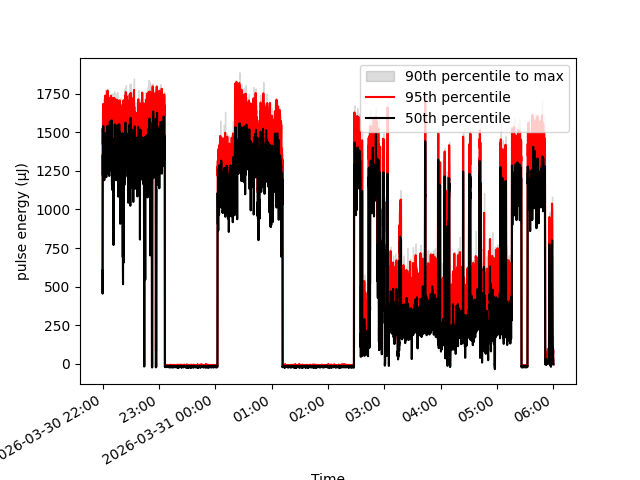

In [5]:
import yaml

from sparklines_plot_utils import get_archive_data
from sparklines_plotting import plot_percentile_band

with open(MONITOR_PVS_FILE, "r", encoding="utf-8") as f:
    monitor_specs = yaml.safe_load(f) or {}
gdet_241 = monitor_specs["GDET 241"]
data = get_archive_data(f"mean_1({gdet_241['pv_name']})", from_time=start, to_time=end)

ax, band_data = plot_percentile_band(
    data,
    window_size=10,
    value_scale=float(gdet_241.get("value_scale", 1.0)),
    y_label='pulse energy (µJ)',
)
plt.show()

Timing test: fetch a single PV

In [6]:
# meme.names.list_pvs(pattern="")

In [7]:
# get_archive_data("BPMS:LTUS:510:TMITSCSHH", from_time=start, to_time=end)
# get_archive_data("BPMS:GUNB:314:FW:X_SLOW", from_time=start, to_time=end)

In [8]:
# HTTP
# get_archive_data("EM1K0:GMD:HPS:milliJoulesPerPulse", from_time=start, to_time=end)

# get_archive_data("EM2K0:XGMD:HPS:milliJoulesPerPulse", from_time=start, to_time=end)

# 

# XLEAP PVs

From David:

In [9]:
import yaml

with open(PV_GROUPS_FILE, "r", encoding="utf-8") as f:
    pv_groups = yaml.safe_load(f) or {}

with open(MONITOR_PVS_FILE, "r", encoding="utf-8") as f:
    monitor_specs = yaml.safe_load(f) or {}

pv_groups


{'groups': [{'group_name': 'matching',
   'description': 'quadrupole magnets used to focus the beam to match design specifications',
   'threshold': 0.05,
   'subgroups': {'IN20': {'Beam_Path': 'CU_SXR, CU_HXR',
     'threshold': 0.002,
     'pv': [{'pv_name': 'QUAD:IN20:121:BCTRL'},
      {'pv_name': 'QUAD:IN20:122:BCTRL'},
      {'pv_name': 'QUAD:IN20:361:BCTRL'},
      {'pv_name': 'QUAD:IN20:371:BCTRL'},
      {'pv_name': 'QUAD:IN20:425:BCTRL'},
      {'pv_name': 'QUAD:IN20:441:BCTRL'},
      {'pv_name': 'QUAD:IN20:511:BCTRL'},
      {'pv_name': 'QUAD:IN20:525:BCTRL', 'threshold': 0.006}]},
    'LI21': {'Beam_Path': 'CU_SXR, CU_HXR',
     'threshold': 0.0025,
     'pv': [{'pv_name': 'QUAD:LI21:201:BCTRL'},
      {'pv_name': 'QUAD:LI21:211:BCTRL'},
      {'pv_name': 'QUAD:LI21:271:BCTRL', 'threshold': 0.004},
      {'pv_name': 'QUAD:LI21:278:BCTRL', 'threshold': 0.009}]},
    'LI26': {'Beam_Path': 'CU_SXR, CU_HXR',
     'threshold': 0.018,
     'pv': [{'pv_name': 'QUAD:LI26:201:BCTRL

# Sparkline Helpers

Utility to create `N` vertically stacked subfigures, each with one axis.

In [10]:
from sparklines_plotting import make_vertical_subfig_axes


In [11]:
from sparklines_plotting import sparklines as _sparklines

def sparklines(pv_data: list[dict], **kwargs) -> None:
    return _sparklines(pv_data, start, end, **kwargs)


# Creating composite PVs

As far as the above sparkplots are concerned, any dict with the following fields can be treated as a PV:
```
{
  'name': <class 'str'>,
  'secondsPastEpoch': <class 'numpy.ndarray'>, 
  'values': <class 'numpy.ndarray'>, 
  'nanoseconds': <class 'numpy.ndarray'>, 
  'severity': <class 'numpy.ndarray'>, 
  'status': <class 'numpy.ndarray'>
}
```

(This is just the standard MEME return format with an added `name` field.)

Thus, we can define our own "composite" PVs that can be plotted with sparklines as long as they have this structure. This could be R56 calculated from a group of quad PVs, for example.

# Tuning Triangles for PV Groups

We want to show something a little more informative than a shaded rectangle for changes to PV groups. Here we define a scheme for representing changes to PV groups as tuning triangles like we did for single PVs.

1. Start with a group of time-varying PVs $v_1(t),v_2(t),\ldots$
2. Define a threshold $\texttt{thr}$ for significant changes in the YAML file for each PV in the group. You may do this at the group level or specify different thresholds for each PV.
3. Normalize each PV to units of its threshold: $u_i(t) = v_i(t)/\texttt{thr}_i$
4. Choose the beginning of the interval as a baseline and define the change in each normalized PV: $\tilde{u}_i(t) = u_i(t) - u_i(0)$
5. Form a "composite PV" for the group from the L1 norm of that change vector, divided by the number of PVs: $V(t) = \frac{1}{N}\lvert\lvert\tilde{\vec{u}}(t)\rvert\rvert_1 = \frac{1}{N}\sum_i |\tilde{u}_i(t)|$
6. Make a sparkline for each group's $V(t)$.

In [12]:
from sparklines_hierarchy import build_composite_hierarchy


In [13]:
# Build all subgroup cPVs, then group cPVs from subgroup cPVs.
composite_hierarchy = build_composite_hierarchy(pv_groups, start, end)
group_composites = [
    node['composite']
    for _, node in sorted(composite_hierarchy['groups'].items())
    if node.get('composite') is not None
]
print(f"Loaded {len(composite_hierarchy['pv_cache'])} PVs")
print(f"Built {sum(len(g['subgroups']) for g in composite_hierarchy['groups'].values())} subgroup composites")
print(f"Built {len(group_composites)} group composites")
print(f"Archive fetch wall time: {composite_hierarchy['timing']['fetch_wall_seconds']:.2f}s")
print(f"Hierarchy build wall time: {composite_hierarchy['timing']['build_wall_seconds']:.2f}s")
print(f"Skipped {len(composite_hierarchy['skipped_pvs'])} PVs with no usable archive payload")
for pv_name, reason in sorted(composite_hierarchy['skipped_pvs'].items()):
    print(f"  {pv_name}: {reason}")
print("Per-PV fetch times (slowest first):")
for pv_name, seconds in sorted(
    composite_hierarchy['timing']['per_pv_fetch_seconds'].items(),
    key=lambda item: item[1],
    reverse=True,
):
    status = composite_hierarchy['skipped_pvs'].get(pv_name)
    suffix = "" if status is None else f" [{status}]"
    print(f"  {seconds:6.2f}s  {pv_name}{suffix}")


Loading PVs from archiver:   0%|          | 0/99 [00:00<?, ?pv/s]

Loaded 84 PVs
Built 22 subgroup composites
Built 5 group composites
Archive fetch wall time: 131.68s
Hierarchy build wall time: 132.70s
Skipped 15 PVs with no usable archive payload
  QUAD:DOG:250:BCTRL: archive error: HTTPConnectionPool(host='lcls-archapp.slac.stanford.edu', port=80): Read timed out. (read timeout=20.0)
  QUAD:DOG:280:BCTRL: archive error: HTTPConnectionPool(host='lcls-archapp.slac.stanford.edu', port=80): Read timed out. (read timeout=20.0)
  QUAD:DOG:335:BCTRL: archive error: HTTPConnectionPool(host='lcls-archapp.slac.stanford.edu', port=80): Read timed out. (read timeout=20.0)
  QUAD:DOG:405:BCTRL: archive error: HTTPConnectionPool(host='lcls-archapp.slac.stanford.edu', port=80): Read timed out. (read timeout=20.0)
  QUAD:EMIT2:150:BCTRL: archive error: HTTPConnectionPool(host='lcls-archapp.slac.stanford.edu', port=80): Read timed out. (read timeout=20.0)
  QUAD:HTR:440:BCTRL: archive error: HTTPConnectionPool(host='lcls-archapp.slac.stanford.edu', port=80): Read t

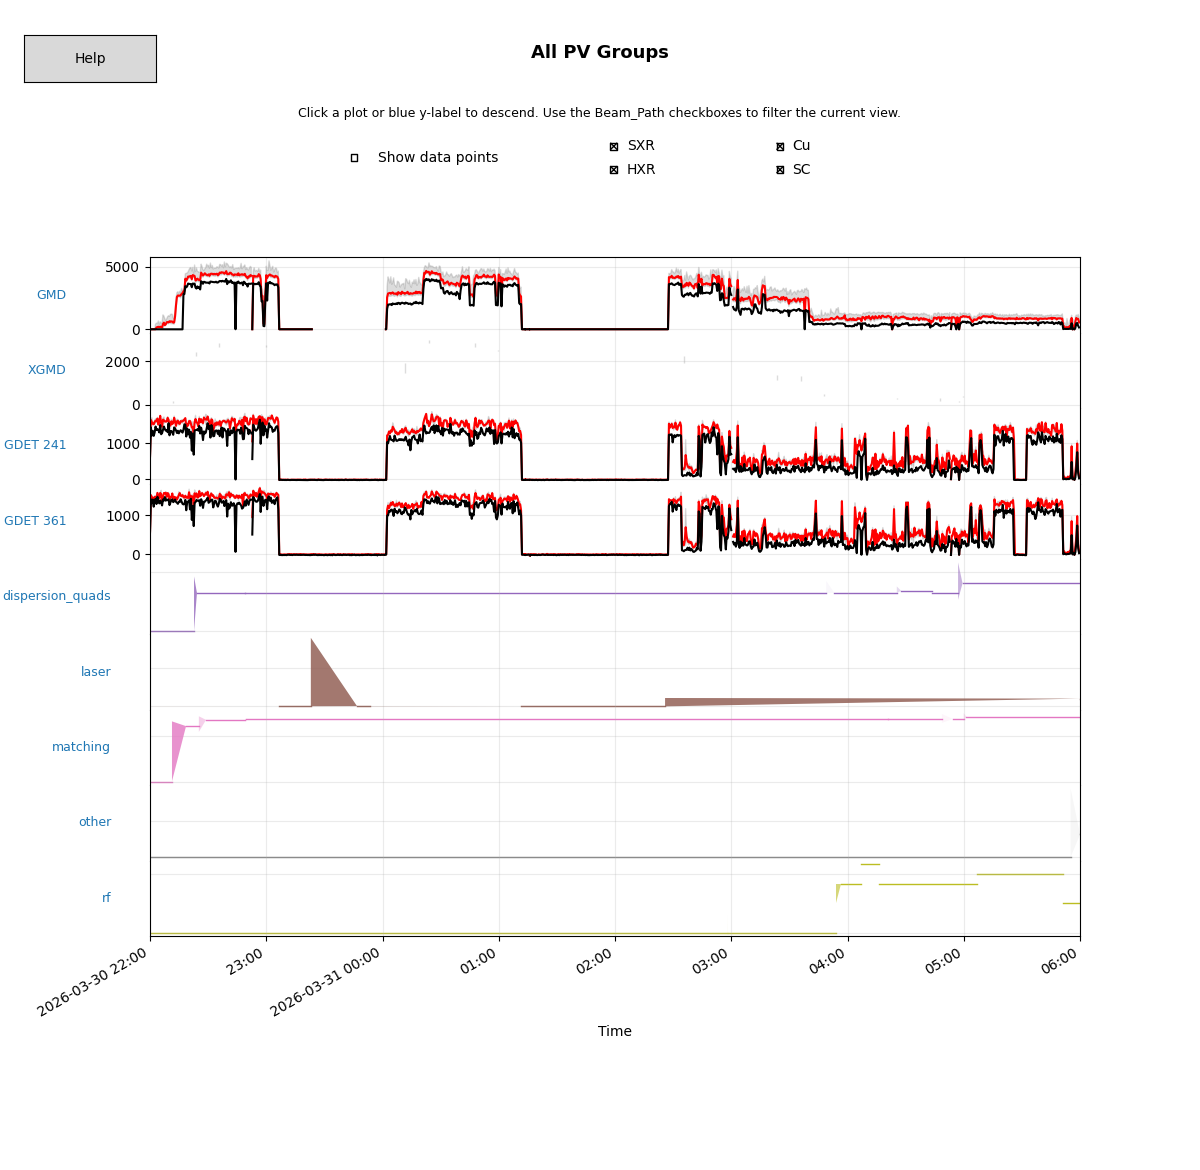

In [14]:
from sparklines_viewer import HierarchySparklineViewer

viewer = HierarchySparklineViewer(composite_hierarchy, start, end)
viewer.draw()



In [15]:
# from time import sleep
# sleep(5)

In [16]:
# plt.close('all')

In [17]:
# filter by beam path (hxr, sxr) x (cu, sc)
# elog button (print to logbook)
# GMD, XGMD, or GDET on every frame (~30s time average)
# 